import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon,MultiPolygon,LineString,LinearRing,MultiPoint,MultiLineString#,Point,box
from shapely.plotting import plot_polygon, plot_line
from shapely.affinity import scale
from shapely import affinity
import numpy as np
from shapely.ops import unary_union
from utils import *
from SwissDWL_Process import *
from Inference.decode_function import *
import os
import imageio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import skfmm


load data

In [2]:
data = pd.read_csv("data/geometries.csv")
area_subtypes_file_path = "area_subtypes_per_usage.csv"
area_subtypes_df = pd.read_csv(area_subtypes_file_path)
# Extract the room_types list
room_types = area_subtypes_df.loc[area_subtypes_df['room'] == 1, 'entity_subtype'].tolist()
apartment_list = data['apartment_id'].unique()
floor_list = data['floor_id'].unique()

# 0: None 1: Living 2: Bath 3: CLoset 4: Bed 5: Kitchen 6: Dining 7: Balcony 8: Corridor 9: end 10: start
# Not used: 9: FOYER and stair 10: Garden and wintergarten 11: outdoor 12: facilities (duct, pipe, etc.)

house_index = (area_subtypes_df['house'] != 0)
floor_index = (area_subtypes_df['publicspace'] != 0)
house_room_types = area_subtypes_df.loc[house_index, 'entity_subtype'].tolist()
floor_room_types = area_subtypes_df.loc[floor_index, 'entity_subtype'].tolist()
house_type_index = area_subtypes_df.loc[house_index, 'house'].tolist()


In [18]:
data[330:380]

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geometry,elevation,height
330,NaN,210,399,1054,1588,NaN,619318.0,PUBLIC,area,SHAFT,POLYGON ((-1.1439038358524964 4.83444375164109...,0.0,2.6
331,NaN,210,399,1054,1588,NaN,662782.0,PUBLIC,area,STAIRCASE,POLYGON ((-4.7898233451230414 2.46782364584592...,0.0,2.6
332,NaN,210,399,1054,1588,NaN,619304.0,PUBLIC,area,SHAFT,POLYGON ((0.6040338936684391 1.309806573621871...,0.0,2.6
333,NaN,210,399,1054,1588,NaN,662782.0,PUBLIC,feature,STAIRS,POLYGON ((-3.4019106761890887 4.38201325472997...,0.0,2.6
334,NaN,210,399,1054,1588,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((0.5548389007820758 1.319019428208344...,0.0,2.6
335,NaN,210,399,1054,1588,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((-1.0959921037073022 -0.6218501760499...,0.0,2.6
336,NaN,210,399,1054,1588,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((-0.2691140277293025 0.29729930136464...,0.0,2.6
337,NaN,210,399,1054,1588,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((-0.5411827085587415 0.50334399571045...,0.0,2.6
338,NaN,210,399,1054,1588,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((0.5491355424740867 1.245936990185365...,0.0,2.6
339,NaN,210,399,1054,1588,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((-2.8607922835442743 4.68565509155788...,0.0,2.6


In [31]:
aa = data.loc[data['apartment_id']==apartment_list[5]]
aa
# aa.loc[aa['entity_type']=='area']

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geometry,elevation,height
284,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619314.0,RESIDENTIAL,area,BALCONY,POLYGON ((6.6332818443542809 1.893154628642479...,5.8,2.60
285,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619315.0,RESIDENTIAL,area,CORRIDOR,POLYGON ((-0.8407103586364295 2.49132970436546...,5.8,2.60
286,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619311.0,RESIDENTIAL,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,5.8,2.60
287,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,5.8,2.60
288,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619310.0,RESIDENTIAL,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341117...,5.8,2.60
289,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619312.0,RESIDENTIAL,area,ROOM,POLYGON ((3.0141380455489282 4.182056855151666...,5.8,2.60
290,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619322.0,RESIDENTIAL,area,ROOM,POLYGON ((6.7557107205191187 2.413369594812586...,5.8,2.60
291,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619311.0,RESIDENTIAL,feature,BATHTUB,POLYGON ((-2.7209231716926485 4.08209607994800...,5.8,0.60
292,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619311.0,RESIDENTIAL,feature,TOILET,POLYGON ((-0.7933835180003026 3.68785005418052...,5.8,0.40
293,2520c37f5c7cf411a9c3a78a66df429e,210,399,1054,1590,7298.0,619311.0,RESIDENTIAL,feature,SINK,POLYGON ((-1.1717635934800619 4.64210312493886...,6.4,0.25


In [ ]:
os.makedirs('parsed/boundary', exist_ok=True) # site img
os.makedirs('parsed/graph', exist_ok=True) # Json layout graph
for i in range(16):
    os.makedirs('parsed/location/%d' % (i), exist_ok=True) 
    os.makedirs('parsed/region/%d' % (i), exist_ok=True) 
os.makedirs('parsed/location_all', exist_ok=True) 
os.makedirs('parsed/region_all', exist_ok=True) 

Parse single FP

In [ ]:
location_onehot_dimension = 25
area_onehot_dimension = 40
parsed_type = np.zeros((45000,14+2))
parsed_loc = np.zeros((45000,14+2,2))
parsed_ada = np.zeros((45000,14+2,14))
parsed_area = np.zeros((45000,14+2))

SwissD = Swiss_Dewelling_DataProcess(house_room_types,house_type_index,location_onehot_dimension,area_onehot_dimension)
indx = 0

for j,k in enumerate(apartment_list):
    tmp = data.loc[data['apartment_id']==k]
    if j%100 == 0:
        print(j)
    if tmp['site_id'].unique().shape[0] == 1:

        if tmp['floor_id'].unique().shape[0] == 0:
            contest_poly = Polygon([[0,0],[0,1],[0,0]])
            floor_id = 0
        else:
            floor_id = tmp['floor_id'].unique()[0]
            contest = data.loc[data['floor_id'] == floor_id]

            contest_poly = parse_contest(contest.index,contest['geometry'])
        try:
            sucess, get_type, get_loc, get_ada, get_area = SwissD.transfer_polygons(tmp,indx,contest_poly)#, get_loc, get_ada, get_area

            if sucess == 1:
                parsed_type[indx] = get_type
                parsed_loc[indx] = get_loc
                parsed_ada[indx] = get_ada
                parsed_area[indx] = get_area
                indx += 1
                SwissD.reset()
        except:
            SwissD.reset()

    else:
        for m,n in enumerate(tmp['site_id'].unique()):

            tmps = data.loc[data['site_id']==n]

            if tmps['floor_id'].unique().shape[0] == 0:
                contest_poly = Polygon([[0,0],[0,1],[0,0]])
                floor_id = 0
            else:
                floor_id = tmps['floor_id'].unique()[0]
                contest = data.loc[data['floor_id'] == floor_id]
                contest_poly = parse_contest(contest.index,contest['geometry'])
            try:
                sucess, get_type, get_loc, get_ada, get_area = SwissD.transfer_polygons(tmp,indx,contest_poly)

                if sucess == 1:
                    
                    parsed_type[indx] = get_type
                    parsed_loc[indx] = get_loc
                    parsed_ada[indx] = get_ada
                    parsed_area[indx] = get_area
                    indx += 1
                    SwissD.reset()
            
            except:
                SwissD.reset()

Parse single FP Fab

In [ ]:
from SwissDFab_Process import Swiss_Dewelling_DataProcess_Fab
location_onehot_dimension = 25
area_onehot_dimension = 40
parsed_type = np.zeros((45000,14+2))
parsed_loc = np.zeros((45000,14+2,2))
parsed_ada = np.zeros((45000,14+2,14))
parsed_area = np.zeros((45000,14+2))
os.makedirs('parsed/new_fab/json', exist_ok=True) # site img
os.makedirs('parsed/new_fab/site', exist_ok=True) # site img
os.makedirs('parsed/new_fab/FP', exist_ok=True) # site img
os.makedirs('parsed/new_fab/partial', exist_ok=True) # site img
SwissD = Swiss_Dewelling_DataProcess_Fab(house_room_types,house_type_index,location_onehot_dimension,area_onehot_dimension)
indx = 0

for j,k in enumerate(apartment_list):
    tmp = data.loc[data['apartment_id']==k]
    if j%100 == 0:
        print(j)
    if tmp['site_id'].unique().shape[0] == 1:

        if tmp['floor_id'].unique().shape[0] == 0:
            contest_poly = Polygon([[0,0],[0,1],[0,0]])
            floor_id = 0
        else:
            floor_id = tmp['floor_id'].unique()[0]
            contest = data.loc[data['floor_id'] == floor_id]
            contest_poly = parse_contest(contest.index,contest['geometry'])
            public = contest.loc[contest['unit_usage']=='PUBLIC']
            stairs = public.loc[public['entity_subtype'] in ['STAIRCASE','ELEVATOR','STAIRS']]
        try:
            sucess, get_type, get_loc, get_ada, get_area = SwissD.transfer_polygons(tmp,indx,contest_poly,public,stairs)#, get_loc, get_ada, get_area

            if sucess == 1:
                parsed_type[indx] = get_type
                parsed_loc[indx] = get_loc
                parsed_ada[indx] = get_ada
                parsed_area[indx] = get_area
                indx += 1
                SwissD.reset()
        except:
            SwissD.reset()

    else:
        for m,n in enumerate(tmp['site_id'].unique()):

            tmps = data.loc[data['site_id']==n]

            if tmps['floor_id'].unique().shape[0] == 0:
                contest_poly = Polygon([[0,0],[0,1],[0,0]])
                floor_id = 0
            else:
                floor_id = tmps['floor_id'].unique()[0]
                contest = data.loc[data['floor_id'] == floor_id]
                contest_poly = parse_contest(contest.index,contest['geometry'])
                public = contest.loc[contest['unit_usage']=='PUBLIC']
                stairs = public.loc[public['entity_subtype'] in ['STAIRCASE','ELEVATOR','STAIRS']]
            try:
                sucess, get_type, get_loc, get_ada, get_area = SwissD.transfer_polygons(tmp,indx,contest_poly)

                if sucess == 1:
                    
                    parsed_type[indx] = get_type
                    parsed_loc[indx] = get_loc
                    parsed_ada[indx] = get_ada
                    parsed_area[indx] = get_area
                    indx += 1
                    SwissD.reset()
            
            except:
                SwissD.reset()

0


/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(


100
200
300
400
500
600
700


/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: divide by zero encountered in intersects
  return lib.intersects(a, b, **kwargs)


800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18500
18600
18700
18800
18900
19

/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


41600
41700
41800
41900
42000
42100
42200
42300
42400
42500
42600
42700
42800
42900
43000
43100
43200
43300
43400
43500
43600
43700
43800
43900
44000
44100
44200
44300
44400
44500
44600
44700
44800
44900
45000
45100


In [8]:
dataall = []
with open('parsed/new_fab/annotations.json', 'w') as outfile:
    for i in range(42449):
        with open(f'parsed/new_fab/json/{i}.json', 'r') as f:
            # Use json.load to read directly from a file object
            data = json.load(f)

            entry = {
                "image": f'{i}.jpg',
                "layout_image": f'{i}.jpg',
                "structured_prompt": data.get("structured_prompt"),
                "fabrication_info": data.get("fabrication_info"),
                "panels": data.get("panels")
            }
            # Attach modules to this entry if present
            if data.get("modules"):
                entry["modules"] = data["modules"]

            dataall.append(entry)
    json.dump(dataall, outfile)
            

Parse 2D building + door + window + Balcony

In [ ]:
color_list = []
base_color = [0,127,255]
for a in range(3):
    for b in range(3):
       for c in range(3):
            if a+b+c>2:
                color_list.append([base_color[a],base_color[b],base_color[c]])
import random
random.shuffle(color_list)
color_list

In [4]:
color_list = [[127, 127, 255],
 [0, 255, 255],
 [127, 255, 0],
 [255, 0, 127],
 [255, 127, 127],
 [255, 0, 255],
 [127, 255, 127],
 [127, 0, 255],
 [0, 255, 127],
 [0, 127, 255],
 [255, 255, 0],
 [0, 0, 255],
 [0, 255, 0],
 [255, 0, 0], # door
 [255, 255, 255],] # public

# color_list = [
#           [255,255,0],#Living
#           [0,255,255],#Bath
#           [255,0,0],#CLoset
#           [255,0,255],#Bed
#           [127,127,255],#Kitchen
#           [0,255,0],#Dining
#           [127,255,127],#Balcony
#           [255,127,127],#Corridor
#           [0,0,255],#line
#           [255,255,255],
#           ]
# input [127, 127, 127]
os.makedirs('parsed/building_input', exist_ok=True)
os.makedirs('parsed/building_segment', exist_ok=True)
os.makedirs('parsed/building_tags', exist_ok=True)
os.makedirs('parsed/building_json', exist_ok=True)


plot with tag

In [7]:
location_onehot_dimension = 25
area_onehot_dimension = 40
res = 512
scale = 48
parsed_type = np.zeros((45000,14+2))
parsed_loc = np.zeros((45000,14+2,2))
parsed_ada = np.zeros((45000,14+2,14))
parsed_area = np.zeros((45000,14+2))

SwissD = Swiss_Dewelling_DataProcess_Floor(house_room_types,house_type_index,location_onehot_dimension,area_onehot_dimension)
indx = 0
# floor_list = data['floor_id'].unique()

for i,j in enumerate(floor_list):
    if i%100 == 0:
        print(i)
    floor = data.loc[data['floor_id'] == j]
    apartment_list = floor['apartment_id'].unique()
    # contest_poly, public_polygon, _, x, y, all, all_type, all_loc 
    # Fixed: capture all_polygon (first return value) instead of discarding it
    all_polygon, _, public_polygon, _, _, _, _, _, x, y, _, _, _, _, _, _= parse_floor2D(floor.index,floor['geometry'],floor['entity_subtype'],floor['elevation'],floor['height'],floor_room_types)
    
    # Extract types and locations from floor data
    all_type = []
    all_loc = []
    for idx_room in floor.index:
        room_type = floor.loc[idx_room, 'entity_subtype']
        room_geom = floor.loc[idx_room, 'geometry']
        # Parse the geometry to get the polygon
        room_coords = room_geom[10:-2].split(",")
        room_corners = []
        for coord in room_coords:
            xy = coord.strip().split(" ")
            if xy[1][-1] == ')':
                xy[1] = xy[1][:-1]
            if xy[0][0] == '(':
                xy[0] = xy[0][1:]
            room_corners.append((float(xy[0]), float(xy[1])))
        from shapely.geometry import Polygon
        room_poly = Polygon(room_corners)
        # Store type and centroid location
        # if room_type not in ['WALL','DOOR','WINDOW','RAILING','SHAFT','ENTRANCE_DOOR']:
        if room_type in house_room_types:
            all_type.append(room_type)
            all_loc.append([room_poly.centroid.x, room_poly.centroid.y])

    # Use all_polygon instead of undefined contest_poly
    contest_poly = all_polygon
    
    if x < scale and y < scale:
        apart_list = []
        door_list = []
        for k,s in enumerate(apartment_list):
            tmp = floor.loc[floor['apartment_id']==s]
            apart,_,_,door = parse_rooms(tmp.index,tmp['geometry'],tmp['entity_subtype'],house_room_types,house_type_index)
            # apart = apart.intersection(contest_poly)
            # apart = apart.difference(public_polygon)
            if apart.geom_type == 'MultiPolygon':
                apart = union_multipoly(apart,0.01)
            apart_list.append(apart)
            if door: door_list.append(door)
        # if 1 < len(apart_list) < 14:
        #     boudnary_center = [contest_poly.centroid.x*res/scale,contest_poly.centroid.y*res/scale] #512/scale
        #     move_x =  res/2 - boudnary_center[0]
        #     move_y =  res/2 - boudnary_center[1]
        #     boundary_cut_coords = scale_to_img(res/scale,move_x,move_y,contest_poly)
        #     # if public_polygon.geom_type=='MultiPolygon': scale_to_img_list(6.4,move_x,move_y,public_polygon.geoms)
        #     # else: public_coords = scale_to_img(6.4,move_x,move_y,public_polygon)
        #     if isinstance(door_list,list): frontdoor_coords = scale_to_img_list(res/scale,move_x,move_y,door_list)
        #     elif door_list!= []: frontdoor_coords = scale_to_img(res/scale,move_x,move_y,door_list)
        #     if isinstance(apart_list,list): apart_coords = scale_to_img_list(res/scale,move_x,move_y,apart_list)
        #     else: apart_coords = scale_to_img(res/scale,move_x,move_y,apart_list)

        #     boundary_cut_coords[np.where(boundary_cut_coords>res-1)] = res-1
        #     boundary_cut_coords[np.where(boundary_cut_coords<0)] = 0
        #     temp_boundrgb = np.zeros((res,res,3))

        #     temp_boundrgb = cv2.fillPoly(temp_boundrgb, boundary_cut_coords.astype(np.int32), color=[255,255,255])
            
        #     temp_in = temp_boundrgb.copy()
            # temp_boundrgb = cv2.fillPoly(temp_boundrgb, boundary_cut_coords.astype(np.int32), color=color_list[-1])

            # if isinstance(public_coords,list): 
            #     for m in public_coords: temp_boundrgb = cv2.fillPoly(temp_boundrgb, m.astype(np.int32), color=color_list[-1])
            # else: 
            #     if public_coords[0].tolist()!=[]: temp_boundrgb = cv2.fillPoly(temp_boundrgb, public_coords.astype(np.int32), color=color_list[-1])
            
            # if isinstance(apart_coords,list) and len(apart_coords)>1: 
            #     for n,m in enumerate(apart_coords): temp_boundrgb = cv2.fillPoly(temp_boundrgb, m.astype(np.int32), color=color_list[n])
            # #temp_boundrgb = cv2.fillPoly(temp_boundrgb, apart_coords.astype(np.int32), color=color_list[0])

            #     if isinstance(frontdoor_coords,list): 
            #         for m in frontdoor_coords: temp_boundrgb = cv2.fillPoly(temp_boundrgb, m.astype(np.int32), color=color_list[-2])
            #     else: temp_boundrgb = cv2.fillPoly(temp_boundrgb, frontdoor_coords.astype(np.int32), color=color_list[-2])

            #     mask = cv2.inRange(temp_boundrgb, np.array([250,250,250]), np.array([255,255,255]))
                    
            #         # Find all contours in the mask
            #     contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
                
            #     # Process all significant contours (multiple rooms of same type)
            #     area = 0
            #     for contour in contours:
            #         area += cv2.contourArea(contour) 

            #     if 100 < area < 1600:
            #         # print(len(apart_coords))
                    
            #         # cv2.imwrite('parsed/building_segment/%d.jpg' % (indx),temp_boundrgb)
            #         # cv2.imwrite('parsed/building_input/%d.jpg' % (indx),temp_in)
            #         # print(list(apart_coords[0][0]))
            #         gg = {

            #             "boundary_Corners": list(boundary_cut_coords[0].reshape(-1)),
            #             "apart": [
            #                 {
            #                     "polygon": list(geo[0].reshape(-1)),
            #                 }
            #                 for indx,geo in enumerate(apart_coords) if type != 0
            #             ]
            #         }
            #         with open(f'parsed/building_json/{indx}.json', "w") as f:
            #             json.dump(gg, f)
            # if indx == 71: break

        fig = plt.figure(1,figsize=[24, 12], dpi=300)
        # Get plot bounds for vertical flip calculation
        bounds = all_polygon.bounds  # (minx, miny, maxx, maxy)
        y_max = bounds[3]
        y_min = bounds[1]
        y_mid = (y_max + y_min) / 2
        
        ax = fig.add_subplot(121)
        plot_polygon(all_polygon, ax=ax, add_points=False)
        ax.invert_yaxis()  # Flip the plot vertically
        ax.set_title('1) Whole Layout')

        ax = fig.add_subplot(122)
        plot_polygon(all_polygon, ax=ax, add_points=False)
        ax.invert_yaxis()  # Flip the plot vertically
        # Adjust text positions for vertical flip
        for j,i in enumerate(all_loc):
            # Flip the y-coordinate: new_y = y_mid + (y_mid - old_y)
            # flipped_y = 2 * y_mid - i[1]
            plt.text(i[0]-1.5, i[1], all_type[j], fontsize=12)
        ax.set_title('2) House tags')
        file_img = 'parsed/building_tags/%d.jpg' % (indx)

        plt.savefig(file_img)
        plt.clf()
        indx += 1

            # try:
            #     sucess, get_type, get_loc, get_ada, get_area = SwissD.transfer_polygons(tmp,indx,contest_poly)#, get_loc, get_ada, get_area
            #     if sucess == 1:
            #         parsed_type[indx] = get_type
            #         parsed_loc[indx] = get_loc
            #         parsed_ada[indx] = get_ada
            #         parsed_area[indx] = get_area
            #         indx += 1
            #         SwissD.reset()
            # except:
            #     SwissD.reset()              

0


/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:18

100


/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:1

200


...

/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:1

13800


/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181:

13900


<Figure size 7200x3600 with 0 Axes>

check floor white

In [22]:
os.makedirs('parsed/building_input_filter', exist_ok=True)
os.makedirs('parsed/building_segment_filter', exist_ok=True)
ids = 0
for s in range(13322):
    temp_boundrgb = cv2.imread('parsed/building_segment/%d.jpg' % (s))
    temp_boundrgb = cv2.resize(temp_boundrgb, (512, 512))
    mask = cv2.inRange(temp_boundrgb, np.array([250,250,250]), np.array([255,255,255]))
        
    # Find all contours in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    # Process all significant contours (multiple rooms of same type)
    area = 0
    for contour in contours:
        area += cv2.contourArea(contour) 

    if 100 < area < 2000:
        temp_in = cv2.imread('parsed/building_input/%d.jpg' % (s))
        temp_in = cv2.resize(temp_in, (512, 512))
        for i in range(3):
            temp_in[:,:,i][np.where(temp_in[:,:,i]==127)] = 255
        cv2.imwrite('parsed/building_segment_filter/%d.jpg' % (ids),temp_boundrgb)
        cv2.imwrite('parsed/building_input_filter/%d.jpg' % (ids),temp_in)
        ids += 1
        if ids % 100 == 0:
            print(ids)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600


In [10]:
floor['building_id'].unique()

array([2086])

In [12]:
#.loc[4013]#['apartment_id']
floor[floor['apartment_id'].isnull().values==True]

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geometry,elevation,height
16325,NaN,1004,2086,5756,9400,NaN,323156.0,PUBLIC,area,VOID,POLYGON ((16.1789564078339332 -28.607517292415...,2.9,2.6
16326,NaN,1004,2086,5756,9400,NaN,657407.0,PUBLIC,area,SHAFT,POLYGON ((13.2820612241204579 -18.595575788392...,2.9,2.6
16327,NaN,1004,2086,5756,9400,NaN,323208.0,PUBLIC,area,VOID,POLYGON ((11.6493252673406786 -13.044414320690...,2.9,2.6
16328,NaN,1004,2086,5756,9400,NaN,323160.0,PUBLIC,area,VOID,POLYGON ((-1.5563103795772619 18.9965423533134...,2.9,2.6
16329,NaN,1004,2086,5756,9400,NaN,323163.0,PUBLIC,area,SHAFT,POLYGON ((-0.4618211758019122 3.06929826263885...,2.9,2.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16412,NaN,1004,2086,5756,9400,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((-3.2691766119957655 15.8849721872310...,2.9,2.6
16413,NaN,1004,2086,5756,9400,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((-0.4152258627499634 2.91442214232645...,2.9,2.6
16414,NaN,1004,2086,5756,9400,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((-2.3511858875191898 9.74064079863669...,2.9,2.6
16415,NaN,1004,2086,5756,9400,NaN,NaN,PUBLIC,separator,WALL,POLYGON ((14.7376356773537758 -23.052616486893...,2.9,2.6


In [ ]:
cc = np.array(aparcount)
plt.figure(figsize=(20, 10))
plt.hist(cc, bins=34, facecolor="blue", edgecolor="black", alpha=0.7)
plt.show()

In [ ]:
Type_out = parsed_type[:42548]
Loc_out = parsed_loc[:42548]
Ada_out = parsed_ada[:42548]
Size_out = parsed_area[:42548]

In [ ]:
np.savez('swissD_np.npz',T = Type_out, L = Loc_out, A = Ada_out, S = Size_out)

2D FrontDoor

In [ ]:
location_onehot_dimension = 25
area_onehot_dimension = 40
parsed_fd = np.zeros((45000,2))

SwissD = Swiss_Dewelling_Frontdoor(house_room_types,house_type_index,location_onehot_dimension,area_onehot_dimension)
indx = 0
for j,k in enumerate(apartment_list):
    tmp = data.loc[data['apartment_id']==k]
    if j%100 == 0:
        print(j)
    if tmp['site_id'].unique().shape[0] == 1:

        if tmp['floor_id'].unique().shape[0] == 0:
            contest_poly = Polygon([[0,0],[0,1],[0,0]])
            floor_id = 0
        else:
            floor_id = tmp['floor_id'].unique()[0]
            contest = data.loc[data['floor_id'] == floor_id]
            contest_poly = parse_contest(contest.index,contest['geometry'])
        try:
            sucess, fd = SwissD.transfer_polygons(tmp,indx,contest_poly)#, get_loc, get_ada, get_area

            if sucess == 1:

                parsed_fd[indx] = fd
                indx += 1
                SwissD.reset()
        except:
            SwissD.reset()

    else:
        for m,n in enumerate(tmp['site_id'].unique()):

            tmps = data.loc[data['site_id']==n]

            if tmps['floor_id'].unique().shape[0] == 0:
                contest_poly = Polygon([[0,0],[0,1],[0,0]])
                floor_id = 0
            else:
                floor_id = tmps['floor_id'].unique()[0]
                contest = data.loc[data['floor_id'] == floor_id]
                contest_poly = parse_contest(contest.index,contest['geometry'])
            try:
                sucess, fd = SwissD.transfer_polygons(tmp,indx,contest_poly)

                if sucess == 1:

                    parsed_fd[indx] = fd
                    indx += 1
                    SwissD.reset()
            
            except:
                SwissD.reset()

In [ ]:
parsed_fd[np.where(parsed_fd<0)] = 0

In [ ]:
door_out = parsed_fd[:42548].astype(np.int32)

In [ ]:
np.save('swissD_frontdoor.npy',door_out)

In [ ]:
Type_out = parsed_type[:42548]
Loc_out = parsed_loc[:42548]
Ada_out = parsed_ada[:42548]
Size_out = parsed_area[:42548]

In [ ]:
np.savez('swissD_np.npz',T = Type_out, L = Loc_out, A = Ada_out, S = Size_out)

2d window + site + graph

In [3]:
location_onehot_dimension = 25
area_onehot_dimension = 40
parsed_type = np.zeros((45000,14+2))
parsed_loc = np.zeros((45000,14+2,2))
parsed_ada = np.zeros((45000,14+2,14))
parsed_area = np.zeros((45000,14+2))

SwissD = Swiss_Dewelling_Window(house_room_types,house_type_index,location_onehot_dimension,area_onehot_dimension)
indx = 0

os.makedirs("GT/boundary_distan_512_window", exist_ok=True)

for j,k in enumerate(apartment_list):
    tmp = data.loc[data['apartment_id']==k]
    if j%100 == 0:
        print(j)
    if tmp['site_id'].unique().shape[0] == 1:

        if tmp['floor_id'].unique().shape[0] == 0:
            contest_poly = Polygon([[0,0],[0,1],[0,0]])
            floor_id = 0
        else:
            floor_id = tmp['floor_id'].unique()[0]
            contest = data.loc[data['floor_id'] == floor_id]
            contest_poly = parse_contest(contest.index,contest['geometry'])
        try:
            sucess, get_type, get_loc, get_ada, get_area = SwissD.transfer_polygons(tmp,indx,contest_poly)#, get_loc, get_ada, get_area

            if sucess == 1:
                parsed_type[indx] = get_type
                parsed_loc[indx] = get_loc
                parsed_ada[indx] = get_ada
                parsed_area[indx] = get_area
                indx += 1
                SwissD.reset()
        except:
            SwissD.reset()

    else:
        for m,n in enumerate(tmp['site_id'].unique()):

            tmps = data.loc[data['site_id']==n]

            if tmps['floor_id'].unique().shape[0] == 0:
                contest_poly = Polygon([[0,0],[0,1],[0,0]])
                floor_id = 0
            else:
                floor_id = tmps['floor_id'].unique()[0]
                contest = data.loc[data['floor_id'] == floor_id]
                contest_poly = parse_contest(contest.index,contest['geometry'])
            try:
                sucess, get_type, get_loc, get_ada, get_area = SwissD.transfer_polygons(tmp,indx,contest_poly)

                if sucess == 1:
                    
                    parsed_type[indx] = get_type
                    parsed_loc[indx] = get_loc
                    parsed_ada[indx] = get_ada
                    parsed_area[indx] = get_area
                    indx += 1
                    SwissD.reset()
            
            except:
                SwissD.reset()

0


/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/hang/anaconda3/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(


KeyboardInterrupt: 

Parse 3D buildings with windows

In [20]:
count = []
apart_list = []
floor_list = []
app = 0
flo = 0
for m,n in enumerate(data['building_id'].unique()):
    apart_list.append(app)
    floor_list.append(flo)
    building = data.loc[data['building_id'] == n]
    floors = building['floor_id'].unique()
    flo += len(floors)
    for i,j in enumerate(floors):
        floor = building.loc[data['floor_id'] == j]
        apartment_list = floor['apartment_id'].unique()
        app += len(apartment_list)
    # apart_list.append(app)

In [19]:
pd.DataFrame(apart_list).to_csv('apart_list.csv')
pd.DataFrame(floor_list).to_csv('floor_list.csv')

In [ ]:
cc = np.array(count)
ccc = cc[np.where(cc<30)]
plt.figure(figsize=(20, 10))
plt.hist(ccc, bins=26, facecolor="blue", edgecolor="black", alpha=0.7)
plt.show()

In [9]:
location_onehot_dimension = 64

# building-floor-apartments-apartment 
graph_detail_type = np.zeros((3184,12,13,14))
graph_detail_loc = np.zeros((3184,12,13,14,2))
graph_detail_ada = np.zeros((3184,12,13,14,14))
graph_detail_area = np.zeros((3184,12,13,14))

# building-floor-apartments 
graph_rough_type = np.zeros((3184,12,13))
graph_rough_loc = np.zeros((3184,12,13,2))
graph_rough_ada = np.zeros((3184,12,13,13))
graph_rough_area = np.zeros((3184,12,13))

build_list = [] # start idx, end idx
floor_list = [] # current floor count, initial idx
apart_list = [] # floor1, floor2...

Z_scale_factor = (2/3)**0.5
os.makedirs('parsed/building_3d/canvas', exist_ok=True)
os.makedirs('parsed/building_3d/sketch', exist_ok=True)

In [ ]:
# pd.DataFrame(build_list).to_csv('build_list.csv')
pd.DataFrame(floor_list).to_csv('floor_list.csv')
pd.DataFrame(apart_list).to_csv('apart_list.csv')

Random Mask and Data Preparation

In [ ]:
R_old = np.load('swissD_R.npy')

for i in range(42548):
    for j in range(16):
        if R_old[i,j,0] == 0:
            R_old[i,j,:] = 32
            continue
        elif j==15:
            R_old[i,j,:] = 32

np.save('swissD_R_token.npy', R_old)

In [2]:
T = np.load('swissD_np.npz')['T']
L = np.load('swissD_np.npz')['L']
A = np.load('swissD_np.npz')['A']
S = np.load('swissD_np.npz')['S']
R = np.load('swissD_R_token.npy')

In [ ]:
T_in = np.concatenate((T,T,T),axis=0)
L_in = np.concatenate((L,L,L),axis=0)
A_in = np.concatenate((A,A,A),axis=0)
S_in = np.concatenate((S,S,S),axis=0)
R_in = np.concatenate((R,R,R),axis=0)
np.savez('swissD_input_Train_3.npz',T=T_in,L=L_in,A=A_in,S=S_in,R=R_in)

In [ ]:
# random mask twice to double the dataset (could be triple)
num_layout = 42548
sqe_length = 16
ada_length = int(16*14)
prepare_MaskPLAN_data_Twice(T, L, A, S, R, num_layout, sqe_length, ada_length)

In [3]:
num_layout = 42548
sqe_length = 16
T_mask1,L_mask1,A_mask1,S_mask1,T_new1, L_new1, A_new1, S_new1 = random_maskdiff_123room(T, L, A, S, num_layout, sqe_length)
T_mask2,L_mask2,A_mask2,S_mask2,T_new2, L_new2, A_new2, S_new2 = random_maskdiff_123room(T, L, A, S, num_layout, sqe_length)
# random_maskdiff_123room
T_mask = np.concatenate((T_mask1,T_mask2),axis=0).astype(np.int32)
L_mask = np.concatenate((L_mask1,L_mask2),axis=0).astype(np.int32)
A_mask = np.concatenate((A_mask1,A_mask2),axis=0).astype(np.int32)
S_mask = np.concatenate((S_mask1,S_mask2),axis=0).astype(np.int32)

T_new = np.concatenate((T_new1,T_new2),axis=0).astype(np.int32)
L_new = np.concatenate((L_new1,L_new2),axis=0).astype(np.int32)
A_new = np.concatenate((A_new1,A_new2),axis=0).astype(np.int32)
S_new = np.concatenate((S_new1,S_new2),axis=0).astype(np.int32)

T_ou = np.concatenate((T_new[:,1:],np.zeros((42548*2,1))),axis=-1).astype(np.int32)
L_ou = np.concatenate((L_new[:,1:],np.zeros((42548*2,1,2))),axis=-2).astype(np.int32)
A_ou = np.concatenate((A_new[:,1:],np.zeros((42548*2,1,14))),axis=-2).astype(np.int32)
S_ou = np.concatenate((S_new[:,1:],np.zeros((42548*2,1))),axis=-1).astype(np.int32)

np.savez('swissD_diff_Mask_room123.npz',T=T_mask,L=L_mask,A=A_mask,S=S_mask)
np.savez('swissD_diff_Output_room123.npz',T=T_ou,L=L_ou,A=A_ou,S=S_ou)
np.savez('swissD_diff_Input_room123.npz',T=T_new,L=L_new,A=A_new,S=S_new)

TypeError: random_maskdiff_123room() missing 1 required positional argument: 'list_len'

room123 Large

In [12]:
num_layout = 42548
loops = 5
sqe_length = 16
T_mask,L_mask,A_mask,S_mask,R_mask,T_new, L_new, A_new, S_new, R_new = random_maskdiff_123roomL(T, L, A, S, R, num_layout, loops, sqe_length)

T_ou = np.concatenate((T_new[:,1:],np.zeros((num_layout*loops,1))),axis=-1).astype(np.int32)
L_ou = np.concatenate((L_new[:,1:],np.zeros((num_layout*loops,1,2))),axis=-2).astype(np.int32)
A_ou = np.concatenate((A_new[:,1:],np.zeros((num_layout*loops,1,14))),axis=-2).astype(np.int32)
S_ou = np.concatenate((S_new[:,1:],np.zeros((num_layout*loops,1))),axis=-1).astype(np.int32)
R_ou = np.concatenate((R_new[:,1:],np.ones((num_layout*loops,1,25))*32),axis=-2).astype(np.int32)

np.savez('swissD_diff_Mask_room123L.npz',T=T_mask,L=L_mask,A=A_mask,S=S_mask,R=R_mask)
np.savez('swissD_diff_Output_room123L.npz',T=T_ou,L=L_ou,A=A_ou,S=S_ou,R=R_ou)
np.savez('swissD_diff_Input_room123L.npz',T=T_new,L=L_new,A=A_new,S=S_new,R=R_new)

In [ ]:
num_layout = 42548
sqe_length = 16
ada_length = int(16*14)
prepare_MaskPLAN_data_Twice75(T, L, A, S, R, num_layout, sqe_length, ada_length)

Dataset Analysis

In [3]:
Swiss_Ana = Swiss_Dewelling_Ana(house_room_types,house_type_index)
for j,k in enumerate(apartment_list):
    tmp = data.loc[data['apartment_id']==k]
    if j%100 == 0:
        print(j)
    if tmp['site_id'].unique().shape[0] == 1:
        Swiss_Ana.transfer_polygons(tmp,j)
    else:
        for m,n in enumerate(tmp['site_id'].unique()):
            tmps = data.loc[data['site_id']==n]
            Swiss_Ana.transfer_polygons(tmps,j)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18

In [10]:
np.arange(30)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

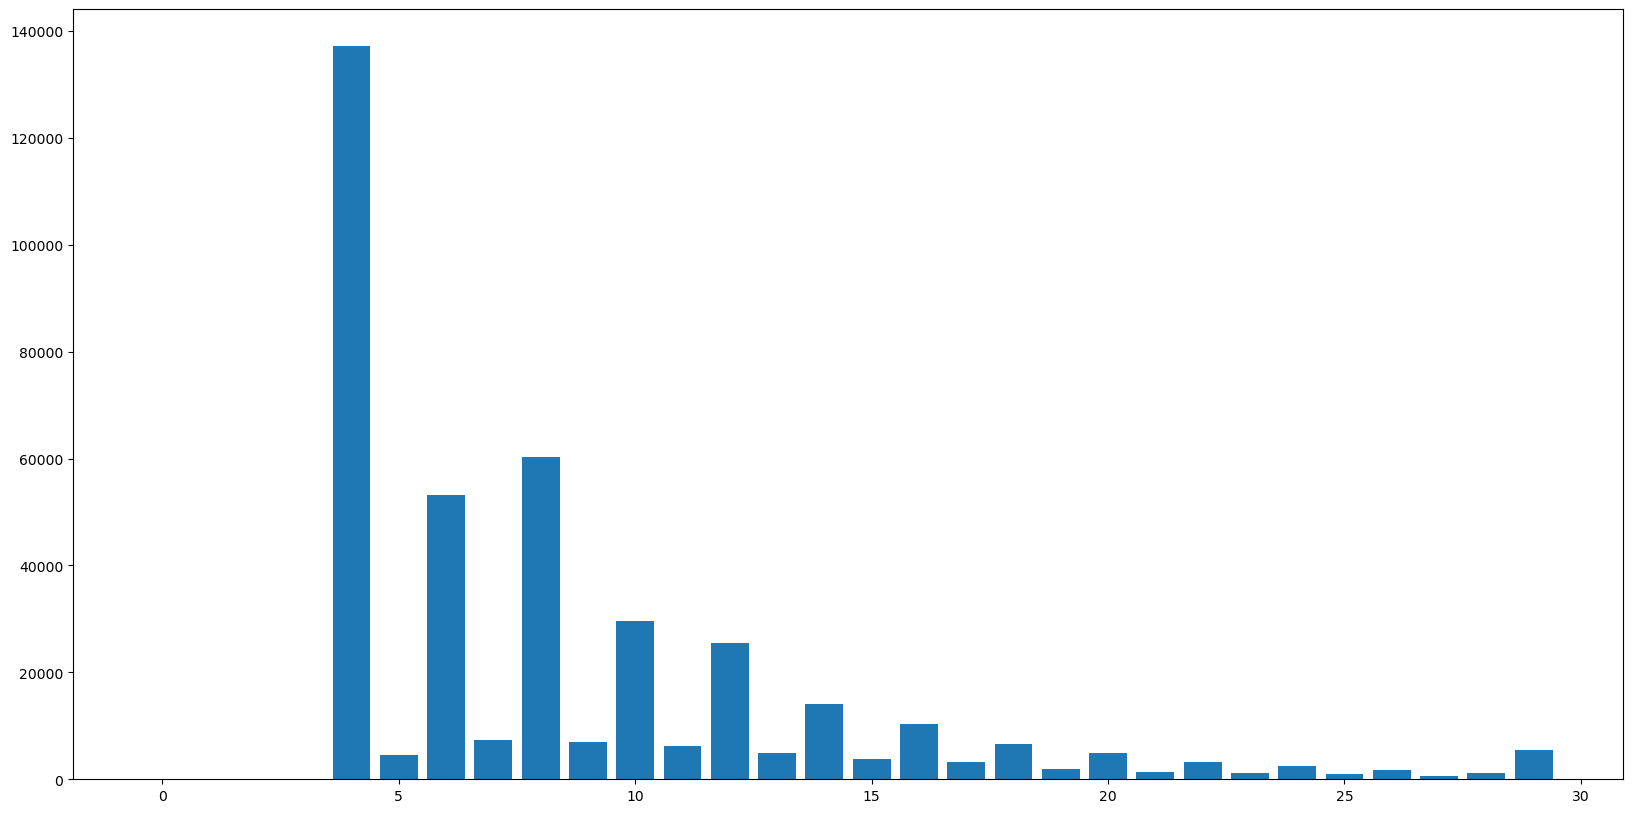

In [11]:
plt.figure(figsize=(20, 10))
plt.bar(np.arange(30),Swiss_Ana.corner_distri)
plt.show()
# Room counts per layout

In [5]:
Swiss_Ana.corner_distri

array([0.00000e+00, 0.00000e+00, 0.00000e+00, 9.00000e+00, 1.37192e+05,
       4.59100e+03, 5.32510e+04, 7.43600e+03, 6.03630e+04, 6.92500e+03,
       2.95410e+04, 6.15200e+03, 2.54740e+04, 4.89900e+03, 1.40920e+04,
       3.83200e+03, 1.04190e+04, 3.17300e+03, 6.52400e+03, 1.95400e+03,
       4.93500e+03, 1.30100e+03, 3.17900e+03, 1.12100e+03, 2.55800e+03,
       9.47000e+02, 1.64700e+03, 5.76000e+02, 1.09400e+03, 5.46500e+03])

In [ ]:
Swiss_Ana.game_scores[1:]/Swiss_Ana.games[1:]

In [ ]:
building_ids = data['building_id'].unique()
t = []
for j,k in enumerate(building_ids):
    a = data.loc[data['building_id'] == k]
    t.append(len(a['floor_id'].unique()))

In [ ]:
np.array(t)[np.where(np.array(t)<7)].shape

In [ ]:
plt.figure(figsize=(20, 10))
plt.hist(t, bins=22, facecolor="blue", edgecolor="black", alpha=0.7)
plt.show()


In [ ]:
types_lib = ['','bathroom','closet','kitchen','bedroom','dining room','balcony','corridor','livingroom']

plt.figure(figsize=(10, 5))
plt.bar(types_lib[1:],[ 1.05627733, 1.05378867, 1.19461832,1.21330031, 
       1.41807779, 1.69268993, 1.73553524,1.9073607 ],)
plt.show()

In [ ]:
np.savez('convexity_area_ana.npz',conv=Swiss_Ana.convexity,area=Swiss_Ana.areas,roomid=Swiss_Ana.convexity_room_id,apartid=Swiss_Ana.convexity_apart_id)

In [ ]:
convexity = np.load('convexity_area_ana.npz')['conv']
area = np.load('convexity_area_ana.npz')['area']

In [ ]:
end = []
types_lib = ['','livingroom','bathroom','closet','bedroom','kitchen','dining room','balcony','corridor']

for i in range(9):
    end.append(np.where(convexity[i]==1000)[0][0])
index = []
for k,j in enumerate(end[1:]):
    index.extend([k+1]*j)
end

In [ ]:
heatmap_np = np.zeros((8,20))

# fractional, integral = np.modf(convexity)
# convexity[np.where(convexity>30)] = 30.9
# area[np.where(area>100)] = 100
areasall = []
apaids = []
roomids = []
counts = []
for i in range(8):
    for j in range(20):
        if j == 0: cond = (convexity[i+1,:end[i+1]]==0)
        else: cond = ((convexity[i+1,:end[i+1]]>j*0.1-0.1)&(convexity[i+1,:end[i+1]]<=j*0.1))
        # areasall.append(np.extract(cond,area[i+1]))
        # apaids.append(np.extract(cond,Swiss_Ana.convexity_apart_id[i+1]))
        # roomids.append(np.extract(cond,Swiss_Ana.convexity_room_id[i+1]))
        heatmap_np[i,j] = np.extract(cond,convexity[i+1]).shape[0]
        counts.append(np.extract(cond,convexity[i+1]).shape[0])


In [ ]:
((np.array([2,5,4,6,8,4])>2)&(np.array([2,5,4,6,8,4])<=6))*np.ones(6)

In [ ]:
os.makedirs('parsed/boundary', exist_ok=True) # site img
os.makedirs('parsed/graph', exist_ok=True) # Json layout graph
for i in range(16):
    os.makedirs('parsed/location/%d' % (i), exist_ok=True) 
    os.makedirs('parsed/region/%d' % (i), exist_ok=True) 
os.makedirs('parsed/location_all', exist_ok=True) 
os.makedirs('parsed/region_all', exist_ok=True) 

In [ ]:
typeid = 0
offset = 25
idd = 1
print(apaids[typeid*27+offset].astype(np.int32)[idd])
print(roomids[typeid*27+offset].astype(np.int32)[idd])

In [ ]:
typeid = 7
index = []
for k,j in enumerate(counts[typeid*27:typeid*27+27]):
    index.extend([k]*j)
index = np.array(index).astype(np.int32)

In [ ]:
start = areasall[typeid*27]
for i in range(typeid*27,typeid*27+26):
    start = np.hstack((start,areasall[i+1]))
df = pd.DataFrame(np.dstack((index,start))[0],columns=['ind', 'value'])
sns.boxplot(df,x="ind",y="value")

In [ ]:
allcout = np.sum(heatmap_np,axis=1)
for k in range(8):
    heatmap_np[k] /= allcout[k]

In [ ]:
plt.figure(figsize=(20, 10))
plt.hist(convexity[1,:end[1]], bins=25, facecolor="blue", edgecolor="black", alpha=0.7)
plt.show()

In [ ]:
df = pd.DataFrame(heatmap_np, 
                  index=['livingroom','bathroom','closet','bedroom','kitchen','dining room','balcony','corridor'],
                  columns=[format(i*0.1, '.1f') for i in range(20)])
# Normalize the DataFrame per row
# df.max(axis=1)
# df_normalized = df.div(df.max(axis=1), axis=0)
# df_normalized
df

In [ ]:
plt.figure(dpi=120)
sns.heatmap(data=df,cmap='viridis')#plt.get_cmap('Greens'))

In [ ]:
# Ensure the normalized values are floats and convert to percentages for labeling
# df_normalized = df.div(df.max(axis=1), axis=0)
df_percentage_labels = (df * 100).astype(float)

# Apply formatting to create percentage strings, ensuring numerical data is handled correctly
formatted_labels = df_percentage_labels.applymap(lambda x: f"{x:.2f}%")
formatted_labels

In [ ]:


# Plotting the normalized heatmap with percentage labels
# plt.figure(dpi=240)
plt.figure(figsize=(18, 6))
sns.heatmap(data=df, cmap='viridis', annot=True, fmt=".2%")
plt.show()

In [ ]:
plt.figure(dpi=120)
sns.heatmap(data=df,cmap=plt.get_cmap('tab20c'))

In [ ]:
start = convexity[1][:end[1]]
for i in range(2,9):
    start = np.hstack((start,convexity[i][:end[i]]))
df = pd.DataFrame(np.dstack((index,start))[0],columns=['ind', 'value'])

In [ ]:
sns.boxplot(df,x="ind",y="value")

In [ ]:
sns.violinplot(df,x="ind",y="value")

In [ ]:
start = area[1][:end[1]]
for i in range(2,9):
    start = np.hstack((start,area[i][:end[i]]))
start[np.where(start>100)] = 100
df = pd.DataFrame(np.dstack((index,start))[0],columns=['ind', 'value'])

In [ ]:
sns.boxplot(df,x="ind",y="value")

In [ ]:
Swiss_Ana.game_scores

In [ ]:
Swiss_Ana.games

In [ ]:
Swiss_Ana.game_scores[1:]/Swiss_Ana.games[1:]

In [ ]:
range_domain = []
for i in range(15,26):
    x = np.where(domain[:,0] < i)
    y = np.where(domain[:,1] < i)
    range_domain.append(np.intersect1d(x,y).shape[0])


In [ ]:
range_domain

In [ ]:
plt.figure(figsize=(20, 10))
plt.bar(range(15,26),range_domain)
plt.show()

In [ ]:
plt.figure(figsize=(20, 10))
plt.bar(house_room_types,Swiss_Ana.type_distribution)
plt.show()

In [ ]:
areas = np.array(Swiss_Ana.area)
areas[np.where(areas > 50)] = 50
plt.figure(figsize=(20, 10))
plt.hist(areas, bins=50, facecolor="blue", edgecolor="black", alpha=0.7)
plt.show()
#room areas distribution

Vectorized Data Visualization

In [ ]:
class Swiss_Dewelling_Data():
    def __init__(self,**kwargs):
        super(Swiss_Dewelling_Data, self).__init__(**kwargs)
        self.floorplan_all_polygon = None
        self.floorplan_house_polygon = None
        self.floorplan_Exhouse_polygon = None
        self.type = None
        self.areas = []
        
    def transfer_polygons(self,tmp,ind,id_name,contest,floor_id):

        corners_all,tpyes_all,corners_house,tpyes_house,types_names,house_centers,corners_Ex_house,room_areas,front_door,room_doors,windows,doorsPt,windowsPt\
            = parse_swiss_dewelling_polygon(tmp.index,tmp['geometry'],tmp['entity_subtype'],0.15,house_room_types,house_type_index)
        self.type = tpyes_house
        self.names = tpyes_all
        self.areas = corners_all
        if self.type != []:

            floorplan_all_polygon = MultiPolygon(corners_all)
            
            floorplan_house_polygon = MultiPolygon(corners_house)

            ada_graph = get_adjacency_graph(corners_Ex_house)
            boundary = unary_union(floorplan_all_polygon.buffer(0.1,join_style=2))
            while boundary.geom_type == 'MultiPolygon':
                boundary = boundary.buffer(0.1,join_style=2)
            boundary_corners = list(boundary.exterior.coords)

            if front_door == None:
                front_door_corners = [[0,0],[0,1],[0,0]]
                front_door = Polygon(front_door_corners)
            else:
                front_door_corners = list(front_door.exterior.coords)
            
            fig, ax = plt.subplots(figsize=[1.28, 1.28])
            ax.set_xlim(-15, 15)
            ax.set_ylim(-15, 15)
            plot_polygon(contest, ax=ax,color=[0,0,0], add_points=False)
            plot_polygon(boundary, ax=ax,color=[1,1,1], add_points=False)
            plot_polygon(front_door, ax=ax,color=[1,0,0], add_points=False)
            plt.xticks([])
            plt.yticks([])
            file_img = 'parsed/boundary/%d_%s.jpg' % (ind, id_name)
            file_json = 'parsed/graph/%d_%s.json' % (ind, id_name)
            floorplan_to_Json(file_json,floorplan_house_polygon,types_names,house_centers,tpyes_house,ada_graph,boundary_corners,front_door_corners,windowsPt,doorsPt)
            plt.savefig(file_img)
            plt.clf()

            fig, ax = plt.subplots(figsize=[10, 10])
            ax.set_xlim(-15, 15)
            ax.set_ylim(-15, 15)
            plot_polygon(contest, ax=ax,color=[0,0,0], add_points=False)
            plot_polygon(floorplan_house_polygon, ax=ax,color=[1,1,1], add_points=False)
            plot_polygon(front_door, ax=ax,color=[1,0,0], add_points=False)
            for j,i in enumerate(house_centers):
                plt.text(i[0]-1.5,i[1],types_names[j],fontsize = 10)
            plt.text(-14,-14,floor_id,fontsize = 10)    
            plt.xticks([])
            plt.yticks([])
            file_img2 = 'parsed/layout/%d_%s.jpg' % (ind, id_name)
            plt.savefig(file_img2)
            plt.clf()

            fig, ax = plt.subplots(figsize=[10, 10])
            ax.set_xlim(-15, 15)
            ax.set_ylim(-15, 15)
            plot_polygon(contest, ax=ax,color=[0,0,0], add_points=False)
            for j,i in enumerate(house_centers):
                plt.text(i[0]-1.5,i[1],types_names[j],fontsize = 10)
                corners_house[j] = corners_house[j].minimum_rotated_rectangle
            plot_polygon(MultiPolygon(corners_house), ax=ax,color=[1,1,1], add_points=False)
            plot_polygon(front_door, ax=ax,color=[1,0,0], add_points=False)
            plt.text(-14,-14,floor_id,fontsize = 10)    
            plt.xticks([])
            plt.yticks([])
            file_img3 = 'parsed/box/%d_%s.jpg' % (ind, id_name)
            plt.savefig(file_img3)
            plt.clf()

In [ ]:
class Swiss_Dewelling_Data():
    def __init__(self,**kwargs):
        super(Swiss_Dewelling_Data, self).__init__(**kwargs)
        self.floorplan_all_polygon = None
        self.floorplan_house_polygon = None
        self.floorplan_Exhouse_polygon = None
        self.type = None
        self.areas = []
        
    def transfer_polygons(self,tmp,ind,id_name):
        # index_head,index_tail = tmp.index[0],tmp.index[-1]
        corners_all,tpyes_all,corners_house,tpyes_house,types_names,house_centers,corners_Ex_house,room_areas,front_door,room_doors,windows,doorsPt,windowsPt\
            = parse_swiss_dewelling_polygon(tmp.index,tmp['geometry'],tmp['entity_subtype'],0.15,house_room_types,house_type_index)
        self.type = tpyes_house
        self.names = tpyes_all
        self.areas = corners_all
        if self.type != []:

            floorplan_all_polygon = MultiPolygon(corners_all)
            
            # floorplan_Exhouse_polygon = MultiPolygon(corners_Ex_house)
            floorplan_house_polygon = MultiPolygon(corners_house)

            self.floorplan_all_polygon = floorplan_all_polygon
            self.floorplan_house_polygon = floorplan_house_polygon
            self.floorplan_Exhouse_polygon = corners_Ex_house

            all_doors = MultiPolygon(room_doors)
            all_windows = MultiPolygon(windows)
            ada_graph = get_adjacency_graph(corners_Ex_house)
            boundary = unary_union(floorplan_all_polygon)
            while boundary.type == 'MultiPolygon':
                boundary = boundary.buffer(0.1,join_style=2)
            boundary_corners = list(boundary.exterior.coords)

            if front_door == None:
                front_door_corners = [[0,0],[0,1],[0,0]]
                front_door = Polygon(front_door_corners)
            else:
                front_door_corners = list(front_door.exterior.coords)
            
            fig = plt.figure(1,figsize=[12, 22], dpi=300)
            fig.xlim(-15, 15)
            fig.ylim(-15, 15)
            ax = fig.add_subplot(421)
            plot_polygon(floorplan_all_polygon, ax=ax, add_points=False)
            ax.set_title('1) Whole Layout')

            ax = fig.add_subplot(422)
            plot_polygon(floorplan_house_polygon, ax=ax, add_points=False)
            for j,i in enumerate(house_centers):
                plt.text(i[0]-1.5,i[1],types_names[j],fontsize = 7)
            ax.set_title('2) House Layout')

            ax = fig.add_subplot(423)
            plot_polygon(floorplan_house_polygon, ax=ax, add_points=False)
            plot_polygon(all_doors, ax=ax,color=[0.8,0,0], add_points=True)
            ax.set_title('3) Doors')

            ax = fig.add_subplot(424)
            plot_polygon(floorplan_house_polygon, ax=ax, add_points=False)
            plot_polygon(all_windows, ax=ax,color=[0.8,0,0], add_points=True)
            ax.set_title('4) Windows')

            ax = fig.add_subplot(425)
            plot_polygon(floorplan_house_polygon, ax=ax, add_points=False)
            plot_polygon(front_door, ax=ax,color=[0.8,0,0], add_points=True)
            ax.set_title('5) Front Door')

            ax = fig.add_subplot(426)
            plot_polygon(floorplan_house_polygon, ax=ax, add_points=False)
            for i in ada_graph:
                plot_line(LineString([(house_centers[i[0]]),(house_centers[i[1]])]), ax=ax, color=[0.8,0,0], add_points=True)
            ax.set_title('6) Layout Graph')

            ax = fig.add_subplot(427)
            plot_polygon(boundary, ax=ax, add_points=False)
            plot_polygon(front_door, ax=ax,color=[0.8,0,0], add_points=True)
            ax.set_title('7) Boundary')

            ax = fig.add_subplot(428)
            plot_polygon(floorplan_house_polygon, ax=ax, add_points=False)
            for j,i in enumerate(house_centers):
                plt.text(i[0]-1,i[1],round(room_areas[j], 3),fontsize = 7)
            ax.set_title('8) Room Size')

            file_img = 'parsed/imgs/%d_%s.png' % (ind, id_name)
            file_json = 'parsed/graph/%d_%s.json' % (ind, id_name)

            floorplan_to_Json(file_json,floorplan_house_polygon,types_names,house_centers,tpyes_house,ada_graph,boundary_corners,front_door_corners,windowsPt,doorsPt)
            plt.savefig(file_img)
            plt.clf()